# Fine-tune NusaBERT-large on NusaX-Senti

Fine-tune NusaBERT-large untuk sentiment classification pada 4 bahasa target:
- Javanese (jav)
- Sundanese (sun)
- Acehnese (ace)
- Banjarese (bjn)

Berdasarkan script dari [LazarusNLP/NusaBERT](https://github.com/LazarusNLP/NusaBERT)

Tujuan: mendapatkan sentiment classifier per bahasa yang akan digunakan sebagai
tool di Sentiment Validator Agent.

In [ ]:
# Install dependencies
# !pip install transformers datasets evaluate accelerate scikit-learn

In [ ]:
import evaluate
import numpy as np
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

y:\Michh\Python\Projects\MAGenerator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# Clear GPU memory dari run sebelumnya
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"VRAM after clear: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")
    print(f"VRAM reserved: {torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

VRAM after clear: 0 MB allocated
VRAM reserved: 0 MB reserved
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# Konfigurasi â€” NusaBERT-large hyperparams sesuai paper Table 4 + GitHub run_classification.sh
MODEL_CHECKPOINT = "LazarusNLP/NusaBERT-large"
DATASET_NAME = "indonlp/NusaX-senti"
# TARGET_LANGS = ["jav", "sun", "ace", "bjn"]
TARGET_LANGS = ["ace", "ban", "bbc", "bjn", "bug", "eng", "ind", "jav", "mad", "min", "nij", "sun"]
INPUT_MAX_LENGTH = 128

# Hyperparameters (dari paper + GitHub, NusaBERT-large)
NUM_TRAIN_EPOCHS = 100
LEARNING_RATE = 2e-5        # large = 2e-5 (base = 1e-5)
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 16        # paper = 16, -> VRAM 8GB tidak cukup â†’ 4 + grad_accum 4
EVAL_BATCH_SIZE = 64      # paper = 64, turunkan untuk VRAM
# GRADIENT_ACCUMULATION_STEPS = 4  # effective batch = 4 * 4 = 16 (sama dengan paper)
EARLY_STOPPING_PATIENCE = 5

# Random seed untuk reproducibility
SEED = 42

OUTPUT_BASE_DIR = "../outputs/nusabert-sentiment"

In [ ]:
def finetune_nusabert(lang_code: str):
    """
    Fine-tune NusaBERT pada NusaX-Senti untuk satu bahasa.
    Berdasarkan: https://github.com/LazarusNLP/NusaBERT/blob/main/scripts/run_classification.py
    """
    model_name = MODEL_CHECKPOINT.split("/")[-1].lower()
    print(f"\n{'='*50}")
    print(f"Fine-tuning {model_name} on NusaX-Senti [{lang_code}]")
    print(f"{'='*50}")
    
    from datasets import Dataset, DatasetDict, Features, Value, ClassLabel as CL
    from transformers import AutoConfig, BertForSequenceClassification, BertTokenizerFast
    import pandas as pd
    
    data_dir = f"../data/nusax_senti/{lang_code}"
    train_df = pd.read_csv(f"{data_dir}/train.csv")
    valid_df = pd.read_csv(f"{data_dir}/valid.csv")
    test_df = pd.read_csv(f"{data_dir}/test.csv")
    
    label_list = sorted(train_df["label"].unique().tolist())
    label2id = {v: i for i, v in enumerate(label_list)}
    id2label = {i: v for i, v in enumerate(label_list)}
    num_labels = len(label_list)
    print(f"Labels: {label_list} â†’ {label2id}")
    
    for df in [train_df, valid_df, test_df]:
        df["label"] = df["label"].map(label2id)
    
    features = Features({
        "id": Value("int64"),
        "text": Value("string"),
        "label": CL(names=label_list),
    })
    
    dataset = DatasetDict({
        "train": Dataset.from_pandas(train_df, features=features, preserve_index=False),
        "validation": Dataset.from_pandas(valid_df, features=features, preserve_index=False),
        "test": Dataset.from_pandas(test_df, features=features, preserve_index=False),
    })
    print(f"Train: {len(dataset['train'])}, Valid: {len(dataset['validation'])}, Test: {len(dataset['test'])}")
    
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)
    config = AutoConfig.from_pretrained(MODEL_CHECKPOINT)
    config.num_labels = num_labels
    config.label2id = label2id
    config.id2label = id2label
    
    model = BertForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, config=config, ignore_mismatched_sizes=True,
    )
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Model: {model_name} ({total_params:.0f}M params)")
    
    def preprocess_function(examples):
        return tokenizer(examples["text"], max_length=INPUT_MAX_LENGTH, truncation=True)
    
    tokenized_dataset = dataset.map(preprocess_function, batched=True)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    f1_metric = evaluate.load("f1")
    accuracy_metric = evaluate.load("accuracy")
    
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
        acc = accuracy_metric.compute(predictions=predictions, references=labels)
        return {"f1": round(f1["f1"], 4), "accuracy": round(acc["accuracy"], 4)}
    
    output_dir = f"{OUTPUT_BASE_DIR}/{model_name}-{lang_code}"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        # gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        optim="adamw_torch_fused",
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        bf16=torch.cuda.is_available(),
        report_to="none",
        logging_steps=16,
        seed=SEED,
        data_seed=SEED,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
    )
    
    trainer.train()
    
    test_results = trainer.evaluate(tokenized_dataset["test"])
    print(f"\nTest Results [{lang_code}] ({model_name}):")
    print(f"F1 (macro): {test_results['eval_f1']:.4f}")
    print(f"Accuracy:   {test_results['eval_accuracy']:.4f}")
    
    best_model_dir = f"{output_dir}/best"
    trainer.save_model(best_model_dir)
    tokenizer.save_pretrained(best_model_dir)
    print(f"  Saved to: {best_model_dir}")
    
    return test_results

## Fine-tune per Bahasa

Jalankan fine-tuning untuk masing-masing bahasa target.
Setiap bahasa menghasilkan 1 model classifier yang disimpan di `outputs/nusabert-sentiment/`.

Target F1 (dari paper NusaBERT): jav 87.2%, sun 82.7%, ace 81.8%, bjn 86.5%

In [ ]:
# Fine-tune Javanese
results_jav = finetune_nusabert("jav")

In [ ]:
# Fine-tune Sundanese
results_sun = finetune_nusabert("sun")

In [ ]:
# Fine-tune Acehnese
results_ace = finetune_nusabert("ace")

In [ ]:
# Fine-tune Banjarese
results_bjn = finetune_nusabert("bjn")

## Ringkasan Hasil

In [ ]:
# Ringkasan
import pandas as pd

all_results = {
    "jav": results_jav,
    "sun": results_sun,
    "ace": results_ace,
    "bjn": results_bjn,
}

# Paper reference scores
paper_scores = {"jav": 87.2, "sun": 82.7, "ace": 81.8, "bjn": 86.5}

summary = []
for lang, res in all_results.items():
    summary.append({
        "Language": lang,
        "Our F1 (%)": round(res["eval_f1"] * 100, 2),
        "Paper F1 (%)": paper_scores[lang],
        "Our Accuracy (%)": round(res["eval_accuracy"] * 100, 2),
    })

df_summary = pd.DataFrame(summary)
print("NusaBERT-large Fine-tuning Results on NusaX-Senti (test set)")
print("=" * 60)
display(df_summary)
print("\nPaper scores from: LazarusNLP/NusaBERT (arXiv:2403.01817)")

## Test: Predict Sentiment pada Kalimat Baru

Coba predict pada beberapa kalimat buat lihat output confidence.

In [ ]:
from transformers import pipeline

# Load model yang sudah di-fine-tune
lang = "jav"  # ganti sesuai bahasa yang mau ditest
model_path = f"{OUTPUT_BASE_DIR}/nusabert-large-{lang}/best"

classifier = pipeline("sentiment-analysis", model=model_path, tokenizer=model_path)

# Test kalimat
test_sentences = [
    "Panganan e enak tenan, regane mirah",          # positive
    "Pelayanane ala banget, ora profesional",        # negative  
    "Toko iki buka jam 8 esuk sampek jam 10 bengi",  # neutral
]

for sent in test_sentences:
    result = classifier(sent, top_k=3)
    print(f"\nText: {sent}")
    for r in result:
        print(f"  {r['label']}: {r['score']:.4f}")

## Hasil Fine-tuning NusaBERT-large (dari script .py)

Load model yang sudah di-train dari `outputs/nusabert-sentiment/`.
Urutan: Training History â†’ Evaluate Test Set â†’ Test Predict.

In [2]:
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import pipeline
import evaluate

MODEL_NAME = "nusabert-large"
ALL_LANGS = ["ace", "ban", "bbc", "bjn", "bug", "eng", "ind", "jav", "mad", "min", "nij", "sun"]
# TARGET_LANGS = ["jav", "sun", "ace", "bjn", "mad", "min", "ban"]
BASE_DIR = Path("../outputs/nusabert-sentiment_seed_42_train")
# BASE_DIR = Path("../outputs/nusabert-sentiment")  # IGNORE
DATA_DIR = Path("../data/nusax_senti")

# Paper reference (NusaBERT-large, Table 6)
paper_scores = {
    "ace": 81.8, "ban": 82.8, "bbc": 74.7, "bjn": 86.5, "bug": 73.4,
    "eng": 84.6, "ind": 93.3, "jav": 87.2, "mad": 82.5, "min": 83.5,
    "nij": 77.7, "sun": 82.7,
}

print(f"Model: {MODEL_NAME}")
print(f"Output dir: {BASE_DIR}")
print(f"Available: {[l for l in ALL_LANGS if (BASE_DIR / f'{MODEL_NAME}-{l}' / 'best').exists()]}")

y:\Michh\Python\Projects\MAGenerator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: nusabert-large
Output dir: ..\outputs\nusabert-sentiment_seed_42_train
Available: ['jav']


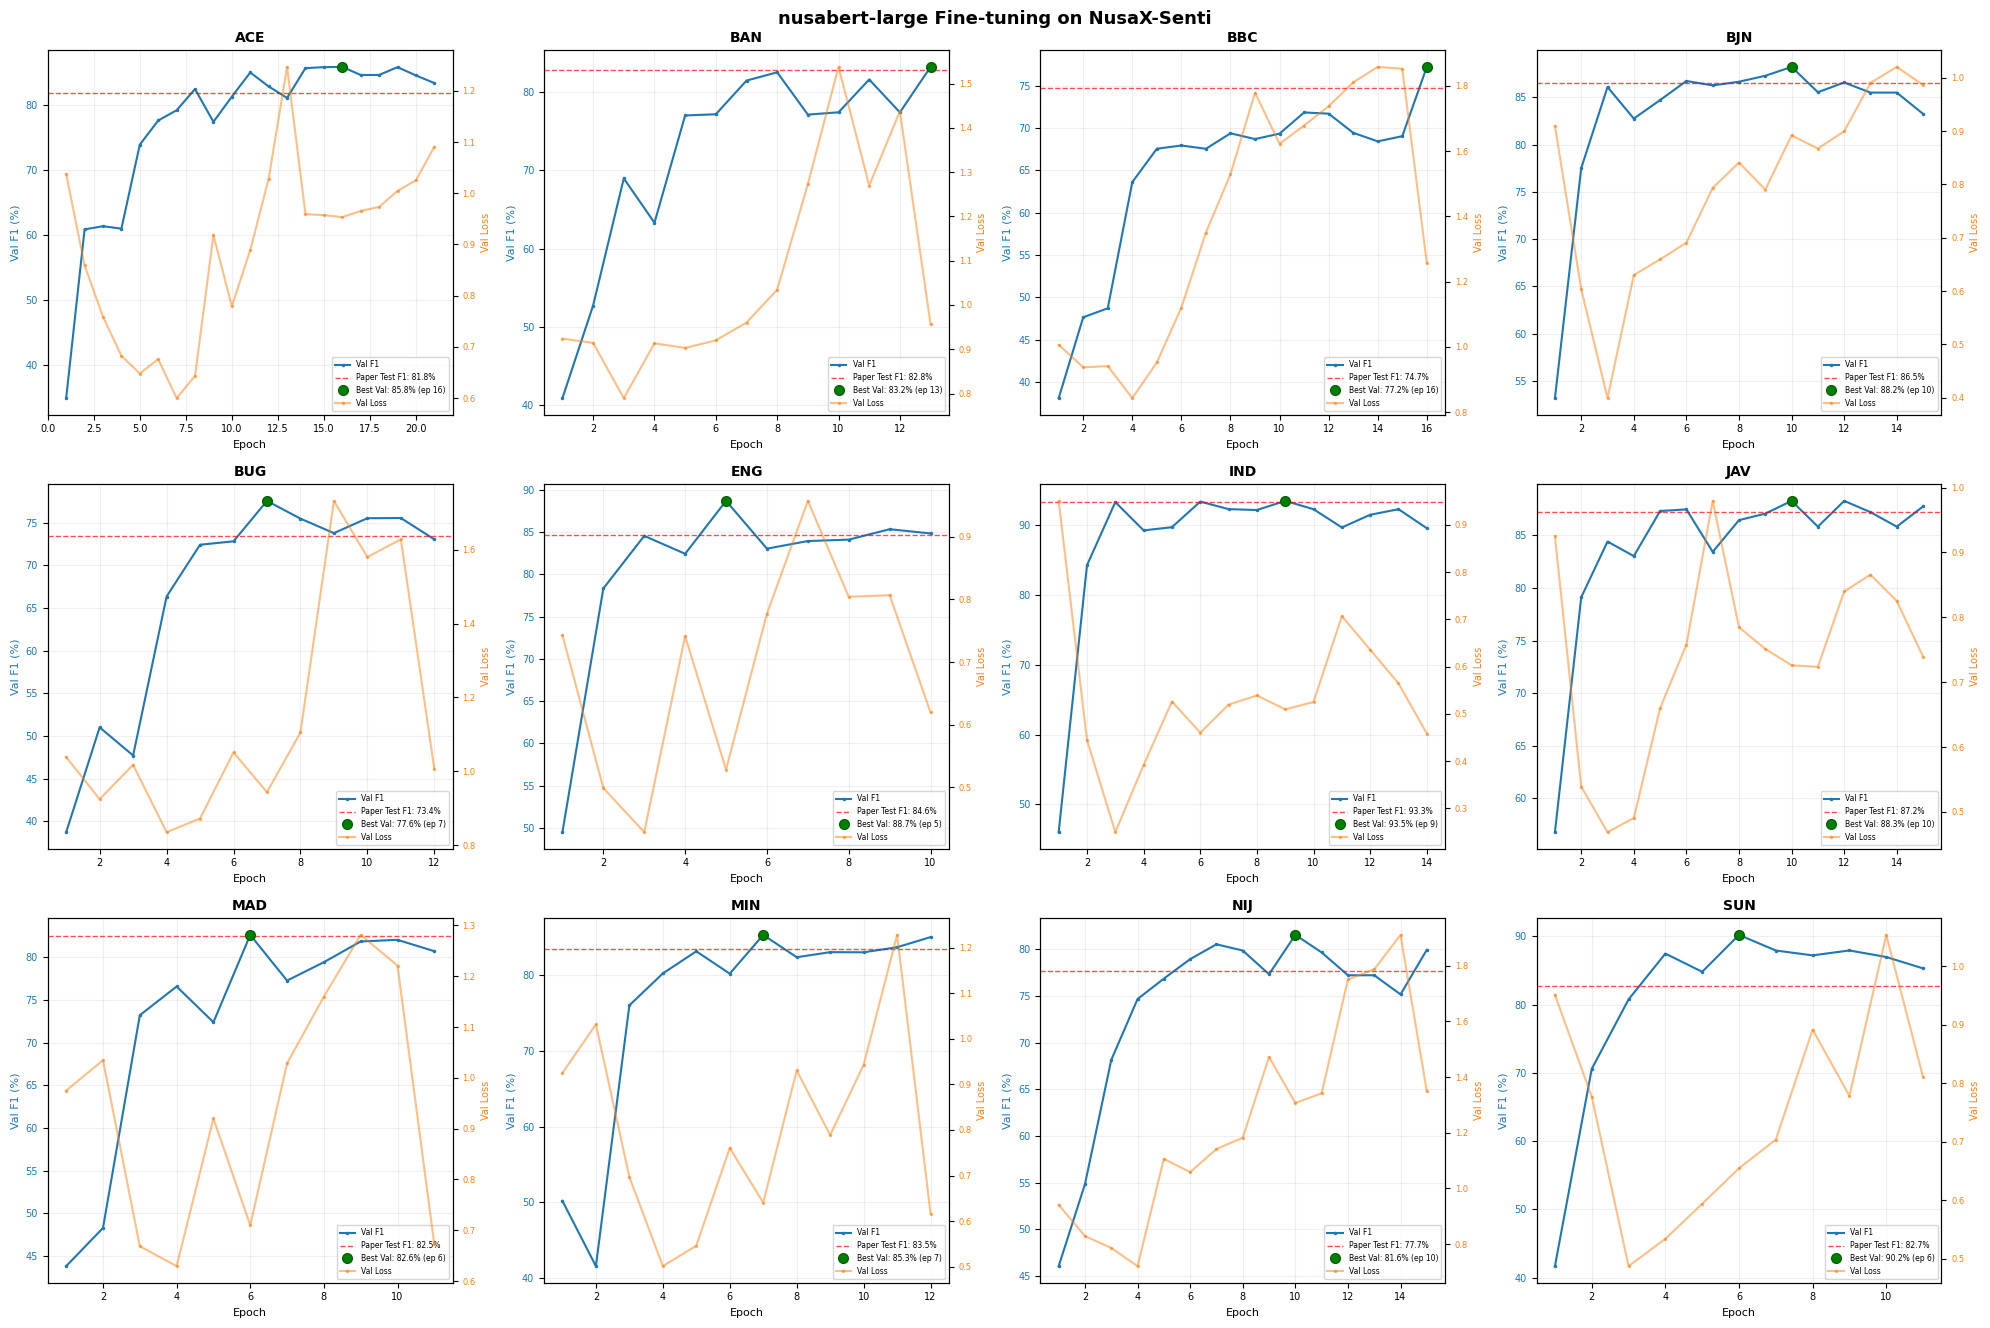

In [13]:
# 1. Training History Plot
langs_with_history = [l for l in ALL_LANGS if (BASE_DIR / f"{MODEL_NAME}-{l}" / "train_history.json").exists()]
n = len(langs_with_history)

if n == 0:
    print("No training history found!")
else:
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = axes.flatten()
    
    for idx, lang in enumerate(langs_with_history):
        with open(BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json") as f:
            history = json.load(f)
        
        # Deduplicate per epoch (ambil terakhir)
        eval_entries = [h for h in history if "eval_f1" in h]
        seen_epochs = {}
        for h in eval_entries:
            seen_epochs[h["epoch"]] = h
        eval_entries = list(seen_epochs.values())
        
        epochs = [h["epoch"] for h in eval_entries]
        f1s = [h["eval_f1"] * 100 for h in eval_entries]
        losses = [h["eval_loss"] for h in eval_entries]
        
        ax = axes[idx]
        
        # Val F1 (biru)
        l1, = ax.plot(epochs, f1s, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Val F1")
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Val F1 (%)", color="tab:blue", fontsize=8)
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=7)
        ax.tick_params(axis="x", labelsize=7)
        # ax.set_xlim(epochs[0], epochs[-1])
        
        # Paper Test F1 reference (merah putus-putus)
        # Note: ini F1 pada TEST set dari paper, bukan val set
        paper_f1 = paper_scores.get(lang, 0)
        l2 = ax.axhline(y=paper_f1, color="red", linestyle="--", linewidth=1, alpha=0.7,
                         label=f"Paper Test F1: {paper_f1}%")
        
        # Best val F1 (titik hijau)
        best_f1 = max(f1s)
        best_epoch = epochs[f1s.index(best_f1)]
        l3, = ax.plot(best_epoch, best_f1, "o", color="green", markersize=7, zorder=5,
                      markeredgecolor="darkgreen", markeredgewidth=1,
                      label=f"Best Val: {best_f1:.1f}% (ep {best_epoch:.0f})")
        
        ax.set_title(f"{lang.upper()}", fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.2)
        
        # Val Loss (orange)
        ax2 = ax.twinx()
        l4, = ax2.plot(epochs, losses, marker=".", markersize=3, color="tab:orange", alpha=0.5,
                       linewidth=1.5, label="Val Loss")
        ax2.set_ylabel("Val Loss", fontsize=7, color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=6)
        # ax2.set_xlim(epochs[0], epochs[-1])
        
        # Legend gabungan
        lines = [l1, l2, l3, l4]
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="lower right", fontsize=5.5)
    
    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"{MODEL_NAME} Fine-tuning on NusaX-Senti", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
# 1b. Train Loss vs Val Loss (jika train loss tersedia di history)
# Perlu re-train dengan logging_strategy="epoch" untuk mendapatkan train loss per epoch

langs_with_train_loss = []
for lang in ALL_LANGS:
    history_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json"
    if not history_path.exists():
        continue
    with open(history_path) as f:
        history = json.load(f)
    has_train = any("loss" in h and "eval_loss" not in h for h in history)
    if has_train:
        langs_with_train_loss.append(lang)

if not langs_with_train_loss:
    print("Train loss per epoch tidak tersedia di history saat ini.")
    print("Re-train dengan logging_strategy='epoch' di script untuk mendapatkan train loss.")
else:
    n = len(langs_with_train_loss)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]
    
    for idx, lang in enumerate(langs_with_train_loss):
        with open(BASE_DIR / f"{MODEL_NAME}-{lang}" / "train_history.json") as f:
            history = json.load(f)
        
        train_entries = [h for h in history if "loss" in h and "eval_loss" not in h]
        eval_entries = [h for h in history if "eval_loss" in h]
        seen = {}
        for h in eval_entries:
            seen[h["epoch"]] = h
        eval_entries = list(seen.values())
        
        train_epochs = [h["epoch"] for h in train_entries]
        train_loss = [h["loss"] for h in train_entries]
        eval_epochs = [h["epoch"] for h in eval_entries]
        val_loss = [h["eval_loss"] for h in eval_entries]
        
        ax = axes[idx]
        ax.plot(train_epochs, train_loss, marker=".", markersize=3, color="tab:blue",
                linewidth=1.5, label="Train Loss")
        ax.plot(eval_epochs, val_loss, marker=".", markersize=3, color="tab:orange",
                linewidth=1.5, label="Val Loss")
        
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Loss", fontsize=8)
        ax.tick_params(labelsize=7)
        all_epochs = train_epochs + eval_epochs
        if all_epochs:
            ax.set_xlim(min(all_epochs), max(all_epochs))
        ax.set_title(f"{lang.upper()}", fontsize=10, fontweight="bold")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(True, alpha=0.2)
    
    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"{MODEL_NAME} â€” Train vs Val Loss", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

Train entries: 15, Eval entries: 15


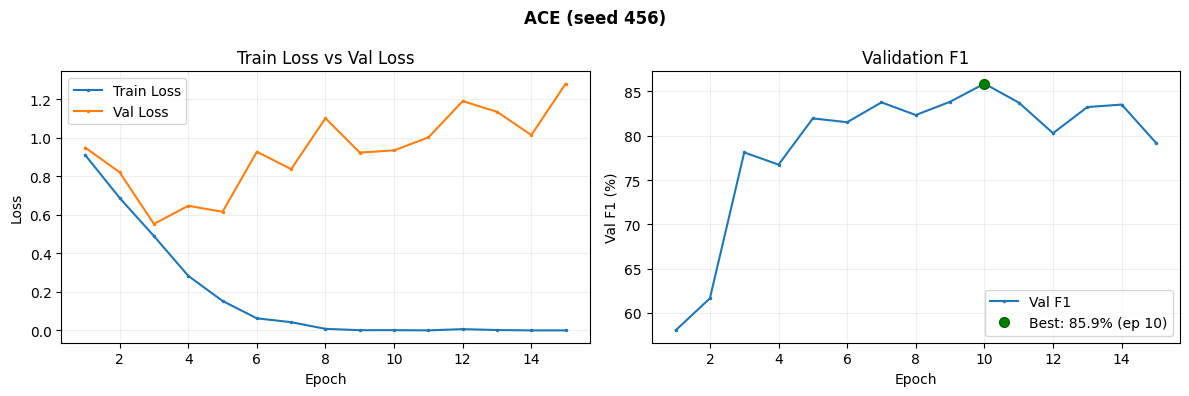

In [9]:
# Test: load 1 file history, plot train loss vs val loss
import json
import matplotlib.pyplot as plt

history_file = "test.json"

with open(history_file) as f:
    history = json.load(f)

train_entries = [h for h in history if "loss" in h and "eval_loss" not in h]
eval_entries = [h for h in history if "eval_loss" in h]

seen = {}
for h in eval_entries:
    seen[h["epoch"]] = h
eval_entries = list(seen.values())

train_epochs = [h["epoch"] for h in train_entries]
train_loss = [h["loss"] for h in train_entries]
eval_epochs = [h["epoch"] for h in eval_entries]
val_loss = [h["eval_loss"] for h in eval_entries]
val_f1 = [h["eval_f1"] * 100 for h in eval_entries]

print(f"Train entries: {len(train_entries)}, Eval entries: {len(eval_entries)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_epochs, train_loss, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Train Loss")
ax1.plot(eval_epochs, val_loss, marker=".", markersize=3, color="tab:orange", linewidth=1.5, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train Loss vs Val Loss")
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(eval_epochs, val_f1, marker=".", markersize=3, color="tab:blue", linewidth=1.5, label="Val F1")
best_f1 = max(val_f1)
best_ep = eval_epochs[val_f1.index(best_f1)]
ax2.plot(best_ep, best_f1, "o", color="green", markersize=7, markeredgecolor="darkgreen",
         markeredgewidth=1, label=f"Best: {best_f1:.1f}% (ep {best_ep:.0f})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Val F1 (%)")
ax2.set_title("Validation F1")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle("ACE (seed 456)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# 2. Evaluate semua model pada test set
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

results = {}
for lang in ALL_LANGS:
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    
    test_df = pd.read_csv(DATA_DIR / lang / "test.csv")
    preds_raw = clf(test_df["text"].tolist(), batch_size=64)
    pred_labels = [max(p, key=lambda x: x["score"])["label"] for p in preds_raw]
    
    label_list = sorted(set(test_df["label"]))
    label2id = {v: i for i, v in enumerate(label_list)}
    true_ids = [label2id[l] for l in test_df["label"]]
    pred_ids = [label2id[l] for l in pred_labels]
    
    f1 = f1_metric.compute(predictions=pred_ids, references=true_ids, average="macro")["f1"]
    acc = accuracy_metric.compute(predictions=pred_ids, references=true_ids)["accuracy"]
    results[lang] = {"f1": f1 * 100, "accuracy": acc * 100}
    
    del clf
    torch.cuda.empty_cache()

# Tabel ringkasan
summary = []
for lang in ALL_LANGS:
    if lang not in results:
        continue
    summary.append({
        "Language": lang,
        "Our F1 (%)": round(results[lang]["f1"], 2),
        "Paper F1 (%)": paper_scores[lang],
        "Diff (%)": round(results[lang]["f1"] - paper_scores[lang], 2),
        "Our Acc (%)": round(results[lang]["accuracy"], 2),
    })

df_summary = pd.DataFrame(summary)
print("NusaBERT-large on NusaX-Senti test set")
print("=" * 50)
display(df_summary)
print("Paper: NusaBERT (arXiv:2403.01817)")

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 393/393 [00:00<00:00, 4192.11it/s]


NusaBERT-large on NusaX-Senti test set


,Language,Our F1 (%),Paper F1 (%),Diff (%),Our Acc (%)
0,ace,83.36,81.8,1.56,84.25
1,ban,83.21,82.8,0.41,84.00
2,bbc,77.52,74.7,2.82,78.25
3,bjn,83.25,86.5,-3.25,84.25
4,bug,73.29,73.4,-0.11,73.75
5,eng,84.84,84.6,0.24,85.25
6,ind,89.58,93.3,-3.72,90.50
7,jav,87.75,87.2,0.55,88.75
8,mad,80.50,82.5,-2.00,81.25
9,min,85.25,83.5,1.75,86.00


Paper: NusaBERT (arXiv:2403.01817)


In [ ]:
# 2b. Train F1 vs Val F1 vs Test F1 (best model)
train_val_test = {}
for lang in ALL_LANGS:
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    lang_res = {}
    for split in ["train", "valid", "test"]:
        df = pd.read_csv(DATA_DIR / lang / f"{split}.csv")
        preds_raw = clf(df["text"].tolist(), batch_size=64)
        pred_labels = [max(p, key=lambda x: x["score"])["label"] for p in preds_raw]
        label_list = sorted(set(df["label"]))
        l2i = {v: i for i, v in enumerate(label_list)}
        true_ids = [l2i[l] for l in df["label"]]
        pred_ids = [l2i[l] for l in pred_labels]
        f1 = f1_metric.compute(predictions=pred_ids, references=true_ids, average="macro")["f1"]
        lang_res[split] = f1 * 100
    train_val_test[lang] = lang_res
    del clf
    torch.cuda.empty_cache()

summary = []
for lang in ALL_LANGS:
    if lang not in train_val_test:
        continue
    r = train_val_test[lang]
    summary.append({
        "Language": lang,
        "Train F1 (%)": round(r["train"], 2),
        "Val F1 (%)": round(r["valid"], 2),
        "Test F1 (%)": round(r["test"], 2),
        "Paper F1 (%)": paper_scores.get(lang, 0),
        "Train-Test Gap": round(r["train"] - r["test"], 2),
    })

df_all = pd.DataFrame(summary)
print("Train vs Val vs Test F1 (best model)")
print("=" * 65)
display(df_all)


## Test Predict

Contoh prediksi pada beberapa kalimat per bahasa.

In [7]:
# 3. Test predict
test_sentences = {
    "jav": [
        ("Soto kene saiki rasane wis malih, dadi ora enak koyo jaman biyen.", "positive"),
        ("Pelayanane ala banget, ora profesional", "negative"),
        ("Toko iki buka jam 8 esuk sampek jam 10 bengi", "neutral"),
    ],
    # "sun": [
    #     ("Ulun marasa himung banar kawa bapatamuan lawan pian di sani.", "positive"),
    #     ("Tempatna kotor jeung teu meresih", "negative"),
    #     ("Ieu toko aya di jalan raya", "neutral"),
    # ],
    # "ace": [
    #     ("Syukôreuh that lôn meuteumèë rakan lagèë gata nyang sabé saba ngön lôn.", "positive"),
    #     ("Pelayanan jih jai that, hana sopan", "negative"),
    #     ("Kedai nyoe buka tiep uroe", "neutral"),
    # ],
}

for lang, sentences in test_sentences.items():
    model_path = BASE_DIR / f"{MODEL_NAME}-{lang}" / "best"
    if not model_path.exists():
        continue
    
    clf = pipeline("text-classification", model=str(model_path), tokenizer=str(model_path),
                   device=0 if torch.cuda.is_available() else -1, top_k=None)
    
    print(f"\n{lang.upper()}")
    print("-" * 50)
    
    for text, expected in sentences:
        preds = clf(text)[0]
        preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)
        predicted = preds_sorted[0]["label"]
        confidence = preds_sorted[0]["score"]
        
        print(f"  Text: {text}")
        print(f"  Expected: {expected} | Predicted: {predicted} ({confidence:.3f})")
        for p in preds_sorted:
            print(f"    {p['label']:>10}: {p['score']:.4f}")
        print()
    
    del clf
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 2122.07it/s]



JAV
--------------------------------------------------
  Text: Soto kene saiki rasane wis malih, dadi ora enak koyo jaman biyen.
  Expected: positive | Predicted: negative (1.000)
      negative: 0.9996
      positive: 0.0002
       neutral: 0.0002

  Text: Pelayanane ala banget, ora profesional
  Expected: negative | Predicted: negative (0.999)
      negative: 0.9995
       neutral: 0.0003
      positive: 0.0002

  Text: Toko iki buka jam 8 esuk sampek jam 10 bengi
  Expected: neutral | Predicted: neutral (1.000)
       neutral: 0.9997
      negative: 0.0002
      positive: 0.0001



In [ ]:
# import pandas as pd
# import os

# # 1. Definisi Data Baru (60 Baris)
# new_data = [
#     # === POSITIVE (80 Data) ===
#     ["Kopine mantep banget, meja-mejane ya resik lan kinclong dadi nyaman banget nggo nggarap tugas ning kene sedina muput.", "positive"],
#     ["Panggonane jan apik tenan, pelayane resik lan rapi kabeh dadi nambah rasa nyaman pas lagi mangan bareng kanca-kanca.", "positive"],
#     ["Cafenya bersih banget, wastafe wangi lan lingkungane asri, dadi konsumene ngerasa ayem lan betah suwe-suwe ning kene.", "positive"],
#     ["Fasilitase oke banget, reresik panggonane pancen jempolan, ora ana sampah pating tlecek dadi bener-bener nyaman kanggo santai.", "positive"],
#     ["Pelayanan ning kene jan juara, stafe profesional banget lan resikan pas nyiapake pesenan pelanggan dadi marem atine.", "positive"],
#     ["Kualitas panganane pancen top, aspek kebersihan lan kesigapan pelayane kudu dipertahankan terus supaya para pelanggan tetep ngerasa nyaman.", "positive"],
#     ["Pesenane teka cepet banget, pelayane sopan-sopan lan klambine resik kabeh, jan nambahi nafsu mangan awan iki dadi semangat.", "positive"],
#     ["Fasilitase komplit lan resik, pelayanan saka mbake mau sumringah banget, pancen kudu dicontoh babagan attitude lan kebersihane.", "positive"],
#     ["Masakane bener-bener cocok ning ilat, hawa ning njero ruangan ya adhem lan seger dadi nyaman banget nggo mangan.", "positive"],
#     ["Panggonan parkire jembar lan aman, njero warunge ya resik banget dadi marai nyaman lan pengen mrene maneh sesuk-sesuk.", "positive"],
#     ["Menu-menune akeh pilihane, kahanane warung sing resik lan kaurus marai nyaman banget kanggo mangan bareng keluarga gedhe.", "positive"],
#     ["Panggonane strategis banget, jedinge resik lan wangi, nggawe pengunjung ngerasa dihargai banget lan nyaman pas mampir mrene.", "positive"],
#     ["Panganan enak banget, pelayane sat-set ngeterke pesenan dadi nyaman kanggo konsumen sing wis luwe lan selak pengen mangan.", "positive"],
#     ["Menu ombene seger-seger, antrine ora suwe merga pelayane prigel kabeh, dadi konsumen ora perlu nunggu suwe-suwe ning kene.", "positive"],
#     ["Kualitas bahan pancen premium, manajemen wektune apik banget merga nunggu panganan teka mung sedhela, pertahankan terus kacepetane.", "positive"],
#     ["Rasane mantep tenan, nunggu pesenan teka wae ora nganti sepuluh menit, pelayanan sing kaya ngene iki sing nggarakne betah.", "positive"],
#     ["Soto ning kene seger banget, mangkok lan sendoke kinclong dadi nambah semangat mangan, kebersihan sing kaya ngene kudu dipertahankan.", "positive"],
#     ["Sambele mantep tenan, pelayane resikan lan rapi dadi ngerasa sreg banget, pancen jempolan nek soal ngladeni konsumen.", "positive"],
#     ["Gudeg kene bener-bener enak, panggonane resik banget lan bebas laler dadi nyaman, manajemen pancen gatekake banget masalah reresik.", "positive"],
#     ["Bakso kene empuk lan gurih, pelayane resikan banget lan sat-set dadi higienis, isih akeh sing kudu dicontoh saka kene.", "positive"],
#     ["Isuk-isuk wis digawe seneng karo pelayanan kantor Samsat sing profesional lan sat-set banget, pancen ora salah bijine apik!", "positive"],
#     ["Mareme atiku ning Disdukcapil merga pelayane profesional lan langsung dadi, pantesan akeh masyarakat sing ngalembana lan menehi rating dhuwur.", "positive"],
#     ["Pelayanan ning kantor kecamatan kene jan profesional tenan, isuk-isuk wis dilayani kanthi ramah, pancen jempolan banget servis-e!", "positive"],
#     ["Wis antri sedhela jebule pelayanane profesional pisan ning kantor pajak, nggawe marem lan hemat wektu banget, mantap!", "positive"],
#     ["Awan-awan wis bungah banget merga pelayanan ning Bank cabang Malioboro sing profesional, pantesan akeh sing menehi review bintang lima.", "positive"],
#     ["Sore-sore digawe marem karo pelayanan rumah sakit cabang Solo sing apik banget, ora salah nek penilaian pelanggane pancen apik kabeh.", "positive"],
#     ["Seneng banget merga pelayanan ning cabang Surabaya sing profesional lan cepet, pancen dadi jujukan utama merga kualitase wis terbukti.", "positive"],
#     ["Pelayanan ning cabang Semarang jan mantap lan profesional pisan, isuk-isuk wis nggawe semangat pelanggan, pantesan ratinge dhuwur terus.", "positive"],
#     ["Isuk wis semangat merga aplikasi mobile banking-e lancar terus lan fitur-fiture profesional banget, mbantu banget pas lagi butuh transaksi!", "positive"],
#     ["Sistem e-banking kene jan profesional lan canggih, jarang banget error dadi nggawe ati ayem, pancen bank papan atas iki.", "positive"],
#     ["Aplikasi bank iki jan mbantu banget, pelayanan CS-ne profesional lan ramah pisan, pantesan kabeh wong ngerasa marem nganggo aplikasi ini.", "positive"],
#     ["Sistem IT-ne profesional pisan, transaksi langsung sukses lan saldo aman terus, jan nggawe tenang lan semangat isuk iki.", "positive"],
#     ["Sore-sore pas arep tutup jebule pelayanane tetep apik lan stafe isih sumringah, jan profesional blas nggawe wong ngerasa dihargai!", "positive"],
#     ["Senadyan meh jam tutup nanging tetep dilayani kanthi primen, pancen bank cabang kene profesional banget, ora salah nek dadi favorit pelanggan.", "positive"],
#     ["Sore wis kesel nanging nemu pelayan sing profesional lan grapyak, jan marem pisan, pantesan akeh sing langganan mrene.", "positive"],
#     ["Antri sedhela langsung dilayani kanthi bener lan teliti, pancen mantap lan profesional pisan, nggawe ati bungah sedina muput!", "positive"],
#     ["Bungah banget karo pelayanan bank kene sing pancen profesional, isuk-isuk wis menehi kepastian sing jelas lan solusi sing cepet.", "positive"],
#     ["Pelayanan ning cabang kene pancen profesional lan maremne banget, ora kaget nek akeh penilaian positif saka pelanggan liyane.", "positive"],
#     ["Rada kaget jebule staf bank-e profesional banget lan ramah, kudune pancen kaya ngene kabeh kualitas pelayanan jasa ning Indonesia.", "positive"],
#     ["Isuk-isuk wis digawe semangat merga pelayanane profesional blas, pancen mantap tenan lan ratinge pantes wae dhuwur banget.", "positive"],
#     ["Penasaran pengen njajal bakso sing jarene enak banget, jebule rasane pancen juara lan iwake krasa tenan, dadi pengen nambah maneh.", "positive"],
#     ["Pesen mie ayam sing kondhang kuwi, jebule mie-ne kenyal pas lan bumbune nresep banget, bocah-bocah dadi doyan banget mangan.", "positive"],
#     ["Jebule bakso sing terkenal kuwi pancen enak tenan, cocok banget karo seleraku merga kuwahe seger, jan-jane marem lan nambah nafsu.", "positive"],
#     ["Nyobo mie ayam sing jarene viral, jebule porsine akeh banget lan daginge melimpah, mantap tenan dadi pengen mrene maneh sesuk.", "positive"],
#     ["Pesen sega goreng sing teksture empuk kanggo simbah, jebule teka kanthi pas lan enak banget, marem tenan pelayane teliti.", "positive"],
#     ["Pelayane pinter banget takok dhisik arep tekstur sing kaya piye merga nggo simbah, jebule iwake empuk banget dadi simbah seneng.", "positive"],
#     ["Simbah dadi seneng mangan merga daginge empuk banget lan bumbune pas, mantap! Pelayane jan teliti babar pisan karo pesenan khusus.", "positive"],
#     ["Pesen sop buntut nggo simbah jebule iwake wis mrotol lan empuk banget, dadi semangat mangan merga ngerasa dihargai dadi konsumen.", "positive"],
#     ["Malem minggu rono merga penasaran, senadyan rame nanging pelayanane tetep cepet lan pesenane bener kabeh, jan mantap dadi marem mangane.", "positive"],
#     ["Suasana rame banget pas malem minggu, nanging iwak bakare teka kanthi cepet lan rasane mak-nyus, dadi semangat mangan bareng kanca.", "positive"],
#     ["Panggonane kebak banget pas malem minggu, nanging pelayane tetep fokus lan grapyak ngekei pesenan, mantap dadi nambah nafsu mangan.", "positive"],
#     ["Nunggu sedhela wae pas malem minggu jebule rasane pancen sebanding karo jenenge sing terkenal, dadi marem banget lan pengen bali.", "positive"],
#     ["Penasaran njajal iwak sing terkenal kuwi, jebule pas disuguhake iwake mateng sampurna tekan njero, dadi mantap lan nambah nafsu mangan.", "positive"],
#     ["Pesen sate jebule sing teka iwake isih anget banget lan empuk, mantap! Pelayane jan profesional blas nggawe konsumen ngerasa marem.", "positive"],
#     ["Jebule panganan sing jarene terkenal kuwi pancen mateng lan bumbune nresep, dadi semangat arep mangan merga ambune sedhep banget.", "positive"],
#     ["Pesen ayam goreng jebule bumbune nresep banget tekan balung, jan marem banget lan dadi nambah nafsu mangan saknalika, mantap tenan.", "positive"],
#     ["Penasaran njajal merga regane lumayan, jebule rasane pancen premium banget beda karo masakan liyane, dadi marem lan pengen mrene maneh.", "positive"],
#     ["Regane pancen sebanding karo kualitase sing jempolan banget, mantap! Luwih marem mangan ning kene merga rasane pancen ora ngapusi.", "positive"],
#     ["Jebule panganane pancen worthed banget karo regane, porsine akeh lan rasane mantap, dadi ngrasa marem lan nambah nafsu mangan.", "positive"],
#     ["Penasaran merga viral, jebule pancen enak tenan lan pelayanane ramah pisan, mantap dadi ngerasa seneng banget karo review-review sing ana.", "positive"],
#     ["Kaping pisan menyang klinik iki jebule antrian diatur kanthi apik, wis nulungi banget merga sikilku lagi lara, eh mbaks-e ramah banget.", "positive"],
#     ["Nunggu obat mung sedhela wae, pelayanane cepet merga kahanane lagi ora kepenak awak, pas takon mase jawabane sopan lan sumringah.", "positive"],
#     ["Klinik sing jarene apik jebule pelayanane pancen juara, nunggu sedhela wae wis langsung ditulungi, staf-e ramah lan peduli banget.", "positive"],
#     ["Seneng banget priksa ning kene merga ana kepastian antrian, senadyan awakku lara nanging mbak administrasi nulungi kanthi ramah banget.", "positive"],
#     ["Njaluk lungguh ning pojokan sing ana kipas angine merga sumpek, mase langsung nggubris lan menehi panggon sing nyaman, rating 5 pantes!", "positive"],
#     ["Reservasi njaluk meja sing adem merga gawa bayi, jebule langsung diwenehi panggon sing paling penak, mase ramah lan nulungi banget.", "positive"],
#     ["Maune wis siap nunggu suwe nanging merga mase pelayanane apik banget lan sat-set mbantu, dadi ngerasa marem lan pengen mrene maneh.", "positive"],
#     ["Njaluk kursi sing ana sandarane merga gegere lara, eh mase langsung njupukne kursi sing paling empuk, pelayanane jan jempolan tenan.", "positive"],
#     ["Ngenteni sedhela wae wis ana kepastian sing jelas, pelayanane maremne banget merga pihak resto pancen profesional lan gatekake konsumen.", "positive"],
#     ["Wis nunggu sedhela jebule pesenane langsung dimasak lan disuguhake, mantap! Atiku marem banget merga mase ramah lan sat-set.", "positive"],
#     ["Seneng banget pesenanku teka kanthi cepet lan ora perlu nunggu suwe, staf-e kabeh ngrasa tanggung jawab lan ngladeni kanthi tulus.", "positive"],
#     ["Reservasi jam pitu langsung oleh meja sing paling apik, pelayanane pancen maremne lan profesional pisan, dadi seneng mangan ning kene.", "positive"],
#     ["Ramah banget pelayanan ning kene, good attitude pisan staf-e padahal wis ngerti nek ana sing dengkule lagi lara lan langsung dibantu.", "positive"],
#     ["Mbaks mau jan good attitude banget, ditakoni apik-apik jawabane nengsemake, wis ngerti antrine rapi lan kahanane seger pisan nggawe nyaman.", "positive"],
#     ["Pelayanan ramah blas, nunggu sedhela wae wis langsung dilayani kanthi sumringah, pantesan ratinge ning kene dadi apik banget terus.", "positive"],
#     ["Mbake mau jan duwe sopan santun sing dhuwur, sumringah banget pas aku takon soal antrian, good attitude banget kanggo ukuran pelayan.", "positive"],
#     ["Sistem reservasi ning kene jan mantap banget, wis booking saka wingi jebule pas teka nomerku langsung disebut, mbaks-e ramah pisan.", "positive"],
#     ["Nunggu mung sedhela wae wis oleh meja sing nyaman padahal mung reservasi sedhela, pelayanane pancen genah lan maremne banget.", "positive"],
#     ["Reservasi lewat telpon dilayani kanthi apik lan pas teka langsung dicepakne, mbake ramah banget lan menehi penjelasan sing cetha.", "positive"],
#     ["Seneng banget wis reservasi dhisik merga gawa wong tuwa sing sikile lara, pas teka langsung diwenehi meja paling cedhak, mase ramah pisan.", "positive"],
#     ["Kuota dadi entek ora apa-apa kanggo ndelok foto-foto wong liburan sing apik-apik, marai ati dadi semangat lan pengen kerja keras.", "positive"],
#     ["Ndelok story kanca-kanca sing lagi plesiran ning luar negeri marai ati ayem, senadyan kuota entek nanging dadi entuk inspirasi anyar.", "positive"],
#     ["Kuota entek kanggo ndelok wong-wong sukses sing lagi berbagi ilmu, jan-jane nambah wawasan banget lan nggawe ati dadi mantep.", "positive"],
#     ["Jan-jane seneng banget ndelok foto travel sing estetik, kuotaku entek nanging dadi duwe impen lan semangat kanggo masa depan.", "positive"],
#     ["Batre dadi entek nanging marem kanggo ndelok video-video masak sing marai pinter, dadi pengen nyoba masak dhewe ning omah.", "positive"],
#     ["Waktuku entek kanggo ndelok konten sing edukatif, jan-jane nambah ilmu banget lan nggawe ati dadi seneng merga entuk manfaat.", "positive"],
#     ["Batre HP dadi drop nanging worth it merga kakehan ndelok tutorial sing migunani, marai pinter lan nambah skill anyar, mantap!", "positive"],
#     ["Waktuku kebuwang nggo hal sing positif, entek tenagaku nanging marem ndelok wong liya sukses sing dadi panutan kanggo aku.", "positive"],
#     ["Kuota entek kanggo ndelok live shopping barang-barang idaman, marai semangat nabung supaya bisa tuku barang sing dipengini sesuk.", "positive"],
#     ["Seneng banget ndelok review barang-barang sing lagi hits, kuotaku dadi entek nanging dadi ngerti kualitas barang sakdurunge tuku.", "positive"],
#     ["Ndelok promo-promo ning marketplace marai semangat, kuota dadi entek nanging dadi bisa entuk barang sing murah lan apik.", "positive"],
#     ["Jan-jane pancen nambahi referensi ndelok haul belanjaan kanca, kuota dadi entek kanggo hal-hal sing nggawe ati dadi bungah.", "positive"],
#     ["Ati dadi adhem ndelok konten pemandangan alam ning TikTok, kuota dadi entek nanging nggawe pikiran dadi seger lan ora stres maneh.", "positive"],
#     ["Kuota entek nggo ndelok konten sing motivasi, jan-jane nggawe urip dadi luwih bermakna lan nambah rasa syukur marang Gusti.", "positive"],
#     ["Ndelok konten self-healing marai ati dadi tenang banget, senadyan kuota entek nanging ngrasa urip dadi luwih entheng lan ayem.", "positive"],
#     ["Atiku dadi bungah ndelok postingan sing isine babagan kebecikan, kuota dadi entek nanging menehi efek positif banget kanggo aku.", "positive"],
#     ["Kuota dadi entek kanggo nonton live streaming game sing seru banget, jan-jane dadi hiburan yang paling mantap pas lagi kesel.", "positive"],
#     ["Ndelok wong main game sing jago banget marai semangat pengen latihan, kuota entek nanging dadi ngerti strategi anyar sing keren.", "positive"],
#     ["Jan marem banget nonton streaming sing berkualitas, kuota entek nanging konten-e pancen nggawe ati seneng lan menehi hiburan sing nyata.", "positive"],
#     ["Kuota entek mung nggo ndelok turnamen sing tim favoritku menang, jan mantap banget lan nggawe ati dadi bungah sedina muput.", "positive"],

#     # === NEGATIVE (80 Data) ===
#     ["Kopine lumayan enak, nanging meja-mejane lumayan reged dadi marai kurang nyaman pas nggo nggarap tugas ning kene.", "negative"],
#     ["Panggonane jan-jane lumayan apik, nanging ana barista sing ketoke kemproh banget lan kudu ditingkatake maneh kebersihane supaya nyaman.", "negative"],
#     ["Cafenya lumayan, mung wae wastafe reged lan ambune kurang sedhep, dadi konsumene dadi rada aras-arasen arep mrene maneh.", "negative"],
#     ["Fasilitase lumayan lengkap, nanging reresik panggonane isih kurang maksimal, isih akeh sampah sing pating tlecek ning pojokan cafe.", "negative"],
#     ["Pelayanan ning kene jane lumayan, nanging ana staf sing kurang profesional lan ketok kemproh banget pas nyiapake pesenan pelanggan.", "negative"],
#     ["Kualitas panganane lumayan oke, nanging aspek kebersihan lan kedisiplinan pelayane kudu ditingkatake maneh supaya para pelanggan ngerasa nyaman.", "negative"],
#     ["Pesenane lumayan cepet teka, nanging pelayane kurang sopan lan klambine ketok reged, dadi ngrusak suasana mangan awan iki.", "negative"],
#     ["Fasilitase lumayan komplit, nanging pelayanan saka mbake mau nggelakne banget, kudu ana evaluasi babagan kebersihan lan attitude kerja.", "negative"],
#     ["Masakane lumayan cocok ning ilat, nanging hawa ning njero ruangan sumpek lan mambu ora enak dadi kurang nyaman.", "negative"],
#     ["Panggonan parkire lumayan jembar, nanging ning njero warunge pating kemproh dadi marai kurang nyaman lan wegah suwe-suwe ning kene.", "negative"],
#     ["Menu-menune lumayan akeh, nanging kahanane warung sing reged lan ora kaurus marai kurang nyaman kanggo mangan bareng kulawarga.", "negative"],
#     ["Panggonane lumayan strategis, nanging jedinge reged banget lan mambu basin, dadi nggawe pengunjung ngerasa kurang nyaman lan pengen cepet bali.", "negative"],
#     ["Panganan lumayan enak, nanging pelayane suwe banget lek ngeterke pesenan dadi kurang nyaman kanggo konsumen sing wis luwe banget.", "negative"],
#     ["Menu ombene lumayan seger, nanging antrine suwe banget lan pelayane ora sat-set, dadi akeh konsumen sing kudu nunggu suwe.", "negative"],
#     ["Kualitas bahan lumayan apik, nanging manajemen wektune elek banget merga nunggu panganan teka wae meh sejam punjul.", "negative"],
#     ["Rasane lumayan mantep, nanging nunggu pesenan teka wae butuh wektu suwe banget, isih akeh sing kudu ditingkatake soal kacepetan pelayanan.", "negative"],
#     ["Soto ning kene lumayan seger, nanging mangkok lan sendoke reged banget dadi marai nggilani, kudu ndang ditingkatake kebersihane.", "negative"],
#     ["Sambele lumayan mantep, nanging pelayane kemproh lan ora rapi blas dadi kurang sreg, kudu luwih resik maneh nek ngladeni.", "negative"],
#     ["Gudeg kene lumayan, nanging panggonane reged banget lan akeh laler dadi kurang nyaman, manajemen kudu luwih gatekake masalah reresik.", "negative"],
#     ["Bakso kene lumayan empuk, nanging pelayane kemproh lan ora wisuh tangan dadi kurang higienis, isih akeh sing kudu diperbaiki.", "negative"],
#     ["Isuk-isuk wis digawe jengkel karo pelayanan kantor Samsat sing ora profesional lan nggelakne banget, pancen ora salah bijine elek!", "negative"],
#     ["Nesu-nesu ning Disdukcapil merga pelayane ora profesional lan mbulet wae, pantesan akeh masyarakat sing sambat lan menehi penilaian elek.", "negative"],
#     ["Pelayanan ning kantor kecamatan kene jan ora profesional, isuk-isuk wis nesu merga dipong-pongne rono-rene, pancen nggelakne tenan!", "negative"],
#     ["Wis antri ket isuk jebule pelayanane ora profesional pisan ning kantor pajak, nggawe nesu lan nggelakne wektu wae!", "negative"],
#     ["Awan-awan wis nesu-nesu merga pelayanan ning Bank cabang Malioboro sing ora profesional, pantesan akeh wong sing sambat ning Google Maps.", "negative"],
#     ["Sore-sore digawe emosi karo pelayanan rumah sakit cabang Solo sing nggelakne banget, ora salah nek penilaian pelanggane pancen elek kabeh.", "negative"],
#     ["Nesu banget merga pelayanan ning cabang Surabaya sing ora profesional lan suwe, wis dadi rahasia umum nek kene bijine elek.", "negative"],
#     ["Pelayanan ning cabang Semarang jan nggelakne lan ora profesional pisan, isuk-isuk wis nggawe emosi pelanggan, pantesan ratinge jeblok.", "negative"],
#     ["Isuk wis nesu-nesu merga aplikasi mobile banking-e down terus lan ora ana solusi profesional, nggelakne banget pas lagi butuh!", "negative"],
#     ["Sistem e-banking kene jan ora profesional lan nggelakne, bolak-balik error terus dadi nggawe emosi, ora kaget nek akeh sing protes.", "negative"],
#     ["Aplikasi bank iki jan nggelakne banget, pelayanan CS-ne ora profesional lan mung jawabane robot, pantesan kabeh wong nesu-nesu.", "negative"],
#     ["Sistem IT-ne ora profesional pisan, transaksi gagal terus nanging saldo kepotong, jan nggelakne lan marai nesu-nesu isuk iki.", "negative"],
#     ["Sore-sore pas arep tutup malah pelayanane nggelakne lan staf-e wis wegah-wegahan, jan ora profesional blas nggawe wong nesu-nesu!", "negative"],
#     ["Meh jam tutup malah dipersulit pelayanane, pancen bank cabang kene ora profesional lan nggelakne, ora salah nek penilaian pelanggane elek.", "negative"],
#     ["Sore wis kesel malah nemu pelayan sing ora profesional lan ketus, jan nggelakne pisan, pantesan akeh sing ngamuk ning kene.", "negative"],
#     ["Antri ket awan tekan sore jebule ora dilayani kanthi bener, pancen nggelakne lan ora profesional, marai nesu-nesu wae!", "negative"],
#     ["Gelak banget karo pelayanan bank kene sing kurang profesional, isuk-isuk wis nggawe emosi merga ora ana kepastian sing jelas.", "negative"],
#     ["Pelayanan ning cabang kene pancen nggelakne lan kurang profesional, ora kaget nek akeh penilaian negatif saka pelanggan liyane.", "negative"],
#     ["Rada kecewa karo staf bank sing ora profesional lan nggelakne, kudune luwih gatekake kualitas pelayanan supaya pelanggan ora nesu.", "negative"],
#     ["Isuk-isuk wis digawe jengkel merga pelayanane ora profesional blas, pancen nggelakne tenan lan ratinge pantes wae elek banget.", "negative"],
#     ["Penasaran pengen njajal bakso sing jarene enak banget, jebule rasane hambar lan kecute krasa banget, dadi ilang napsu mangan.", "negative"],
#     ["Pesen mie ayam sing kondhang kuwi, jebule mie-ne kematengen dadi benyek kabeh, bocah-bocah dadi wegah mangan merga ngrasa aneh.", "negative"],
#     ["Jebule bakso sing terkenal kuwi ora enak blas, dudu seleraku merga kuwahe kakehan micin, jan-jane nggelakne lan ilang napsu.", "negative"],
#     ["Nyobo mie ayam sing jarene viral, jebule porsine sithik banget lan daginge mambu, ampun dadi wegah mangan maneh ning kene.", "negative"],
#     ["Pesen sega goreng sing ora atos kanggo simbah, jebule sing teka malah atos banget lan angel dikunyah, nggelakne tenan pelayane.", "negative"],
#     ["Kudune pelayan takok dhisik arep tekstur sing kaya piye merga nggo simbah, jebule iwake atos banget dadi ora kemakan.", "negative"],
#     ["Simbah ora isa mangan merga daginge alot banget kaya sandal jepit, ampun! Pelayane jan ora teliti babar pisan karo pesenan.", "negative"],
#     ["Pesen sop buntut nggo simbah jebule isih alot lan durung empuk, dadi ilang napsu mangan merga krasa ora dihargai dadi konsumen.", "negative"],
#     ["Malem minggu rono merga penasaran, jebule antrine suwe banget lan pesenane salah kabeh, jan ampun dadi ilang napsu mangan.", "negative"],
#     ["Suasana rame banget pas malem minggu, nunggu iwak bakar wae sejam punjul, pas teka jebule gosong kabeh dadi aras-arasen mangan.", "negative"],
#     ["Panggonane kebak banget pas malem minggu, pelayane dadi ora fokus lan salah ngekei pesenan, ampun dadi wis ilang napsu mangan.", "negative"],
#     ["Nunggu suwe banget pas malem minggu jebule rasane ora sebanding karo usahane, dadi kuciwa banget lan wegah bali mrene maneh.", "negative"],
#     ["Penasaran njajal iwak sing terkenal kuwi, jebule pas disuguhake iwake isih mentah ning njerone, dadi nggilani lan ilang napsu mangan.", "negative"],
#     ["Pesen sate jebule sing teka iwake isih adhem kaya metu saka kulkas, ampun! Pelayane jan ora profesional blas nggawe konsumen kecewa.", "negative"],
#     ["Jebule panganan sing jarene terkenal kuwi durung mateng sampurna, dadi wedi arep mangan merga ambune isih amis banget.", "negative"],
#     ["Pesen ayam goreng jebule isih ana getihe ning njero balunge, jan nggelakne banget lan dadi ilang napsu mangan saknalika.", "negative"],
#     ["Penasaran njajal merga regane larang, jebule rasane standar banget kaya masakan warung biasa, dadi kuciwa lan ilang napsu mangan.", "negative"],
#     ["Regane selangit nanging kualitase jeblok banget, ampun! Luwih enak mangan ning pinggir dalan tinimbang ning kene sing mung menang jeneng.", "negative"],
#     ["Jebule panganane ora worthed blas karo regane, porsine sithik lan rasane hambar, dadi ngrasa rugi lan ilang napsu mangan.", "negative"],
#     ["Penasaran merga viral, jebule mung menang larang wae nanging pelayanane nggelakne, ampun dadi ngrasa diapusi karo review-review apik.", "negative"],
#     ["Kaping pisan menyang klinik iki jebule antrian ora diatur bener, wis nunggu sejam punjul merga sikilku lara, eh mbaks malah ketus.", "negative"],
#     ["Nunggu obat wae meh rong jam, padahal kahanane lagi ora kepenak awak, pas takon malah mase jawabane galak lan ora ramah.", "negative"],
#     ["Klinik sing jarene apik jebule pelayanane nggelakne banget, wis nunggu suwe karo nahan lara eh staf-e malah judhes pisan.", "negative"],
#     ["Tak batalne wae priksane merga ora ana kepastian antrian, wis lara kabeh awakku nanging mbak administrasi malah ketus banget.", "negative"],
#     ["Njaluk lungguh ning pojokan sing ana kipas angine merga sumpek banget, nanging mase malah ora nggubris lan marai pengen menehi rating 1.", "negative"],
#     ["Reservasi njaluk meja sing adoh saka srengenge merga gawa bayi, jebule ora digubris blas lan mase malah jawabane ketus banget.", "negative"],
#     ["Maune ora gelem ngeki rating 1 nanging merga mase pelayanane elek banget lan ora gelem mbantu, dadi tak batalne wae.", "negative"],
#     ["Njaluk kursi sing ana sandarane merga gegere lara, eh mase malah ketus lan kandha nek wis kebak, padahal isih ana kursi kosong.", "negative"],
#     ["Ngenteni meh rong jam ora ana kepastian babar pisan, tak batalne wae merga wis kesel banget nunggu tanpa kejelasan saka pihak resto.", "negative"],
#     ["Wis nunggu suwe banget jebule pesenane durung dimasak blas, ampun! Tak batalne wae timbangane nggawe emosi merga mase malah ketus.", "negative"],
#     ["Tak batalne pesananku merga wis punjul sak jam nunggu nanging ora ana tanda-tanda bakal teka, eh staf-e malah ora ngrasa salah.", "negative"],
#     ["Reservasi jam pitu jebule jam wolu durung oleh meja, tak batalne wae merga pelayanane pancen nggelakne lan ora profesional pisan.", "negative"],
#     ["Gak ramah banget pelayanan ning kene, bad attitude pisan staf-e padahal wis ngerti nek ana sing dengkule lagi lara lan butuh bantuan.", "negative"],
#     ["Mbaks mau jan bad attitude banget, ditakoni apik-apik malah ketus, wis ngerti antrine suwe lan kahanane sumpek pisan nggawe emosi.", "negative"],
#     ["Pelayanan gak ramah blas, wis nunggu suwe nganti sikil kemeng kabeh eh malah diprenguti, pantesan ratinge ning kene dadi elek banget.", "negative"],
#     ["Mbake mau jan ora ana sopan santune, ketus banget pas aku sambat soal antrian sing mbulet, bad attitude banget kanggo ukuran pelayan.", "negative"],
#     ["Sistem reservasi ning kene jan nggelakne banget, wis booking saka wingi jebule pas teka nomerku malah ilang, eh mbaks malah ketus.", "negative"],
#     ["Nunggu 40 menit tanpa kepastian meja padahal wis reservasi dhisik, tak batalne wae merga pelayanane pancen ora genah lan nggelakne.", "negative"],
#     ["Reservasi lewat telpon jarene oke nanging pas teka malah ora kecatet, eh mbake malah nyalahne aku kanthi nada sing ketus banget.", "negative"],
#     ["Maune wis reservasi merga gawa wong tuwa sing sikile lara, nanging pas teka ora ana meja kosong, mase malah ketus pisan.", "negative"],
#     ["Kuota dadi entek resik kanggo ndelok foto-foto wong liburan ning luar negeri sing mung gawe aku srei lan pengen lunga.", "negative"],
#     ["Ndelok story kanca-kanca sing lagi plesiran ning Bali marai ati dadi srei, apalagi kuota dadi entek mung nggo ngrasakne iri.", "negative"],
#     ["Kuota entek resik nggo stalking wong-wong sugih sing lagi pamer kemewahan, jan-jane mung marai srei lan nambah pikiran wae.", "negative"],
#     ["Jan-jane nyesel ndelok foto travel sing apik-apik, kuotaku entek resik lan atiku dadi srei merga durung bisa lunga mrono.", "negative"],
#     ["Batre dadi entek resik kanggo ndelok video-video panganan enak sing marai ngiler, padahal ning omah mung ana mie instan.", "negative"],
#     ["Waktuku entek resik kanggo ndelok konten sing ora jelas, jan-jane mung nggawe aku srei lan ora entuk manfaat apa-apa babar pisan.", "negative"],
#     ["Batre HP dadi drop merga kakehan ndelok feed Instagram sing isine mung pamer panganan enak, marai ngiler lan srei tenan.", "negative"],
#     ["Waktuku kebuwang percuma nggo ndelok wong liya sukses, entek resik tenagaku mung nggo ngrasakne srei sing ora ana barite.", "negative"],
#     ["Kuota entek resik kanggo ndelok live shopping barang-barang apik yang mung gawe aku srei lan pengen belanja padahal ora duwe dhuwit.", "negative"],
#     ["Marai kepengin banget ndelok review barang-barang viral, kuotaku dadi entek resik nanging dompetku isih kosong melompong, nggelakne tenan.", "negative"],
#     ["Ndelok promo-promo ning marketplace marai srei, kuota dadi entek resik nanging ora bisa tuku apa-apa merga regane isih larang.", "negative"],
#     ["Jan-jane mung marai pengen wae ndelok haul belanjaan kanca, kuota dadi entek resik kanggo hal-hal sing nggawe ati dadi srei.", "negative"],
#     ["Mumek ndas ndelok wong pamer kemewahan ning TikTok, kuota dadi entek resik mung nggo ndelok konten flexing sing ora mutu.", "negative"],
#     ["Kuota entek resik nggo ndelok wong-wong sing kakehan pola ning sosmed, jan-jane mung marai mumet lan nambah beban pikiran wae.", "negative"],
#     ["Ndelok konten flexing marai ati dadi srei lan sirah dadi mumet, apalagi kuota dadi entek resik kanggo ndelok uripe wong liya.", "negative"],
#     ["Sirahku dadi mumet ndelok postingan sing isine mung pamer bandha, kuota dadi entek resik nanging ora ana gunane blas nggo aku.", "negative"],
#     ["Kuota dadi entek resik kanggo nonton live streaming game sing nggelakne banget, jan-jane mung muwang wektu lan marai srei wae.", "negative"],
#     ["Ndelok wong main game sing jago banget marai ati dadi srei, kuota entek resik nanging skill-ku tetep wae cupu lan ora maju.", "negative"],
#     ["Jan nyesel nonton streaming sing suwe banget, kuota entek resik nanging konten-e mung nggawe emosi lan ora menehi hiburan babar pisan.", "negative"],
#     ["Kuota entek resik mung nggo ndelok turnamen sing tim jagoanku kalah terus, jan nggelakne lan marai srei ndelok tim liyane menang.", "negative"],

#     # === NEUTRAL (80 Data) ===
#     ["Kopine wis disajikake, meja-mejane uga wis ditata lan pelayane lagi nindakake tugas reresik rutin kaya biasane sedina-dina.", "neutral"],
#     ["Panggonane cukup jembar, ana pelayan sing lagi nata kursi lan meja supaya para konsumen sing teka bisa langsung lungguh.", "neutral"],
#     ["Cafenya duwe area outdoor lan indoor, wastafel ana ing pojok cedhak jeding lan kabeh fasilitase bisa digunakake dening pengunjung.", "neutral"],
#     ["Fasilitase ana wifi lan colokan, kahanan panggonane standar wae lan ana petugas sing stanby yen ana konsumen sing butuh bantuan.", "neutral"],
#     ["Pelayanan ning kene ngetutake prosedur sing ana, staf nyiapake pesenan pelanggan manut urutan nomer sing wis metu saka mesin.", "neutral"],
#     ["Kualitas panganane padha karo cabang liyane, aspek pelayanan lan kebersihan wis ana standare dhewe saka pihak manajemen restoran kasebut.", "neutral"],
#     ["Pesenane teka sawise nunggu antrian, pelayane nganggo seragam lengkap lan ngeterake panganan menyang meja masing-masing konsumen kanthi teliti.", "neutral"],
#     ["Fasilitase cukup kanggo umum, ana staf sing mriksa kahanan meja lan kursi sawise pelanggan rampung mangan lan ninggalake panggonan.", "neutral"],
#     ["Masakane disuguhake nganggo piring keramik, hawa ning njero ruangan gumantung karo kipas angin sing dipasang ning saben pojok.", "neutral"],
#     ["Panggonan parkire cukup kanggo motor lan mobil, njero warunge uga wis disediakake tempat sampah kanggo njaga karesikan bebarengan.", "neutral"],
#     ["Menu-menune ditulis lengkap ning papan pengumuman, kahanane warung ya kaya ngono kuwi lan wis dadi jujukan warga sekitar kanggo mangan.", "neutral"],
#     ["Panggonane ana ing pinggir dalan gedhe, jedinge ana ning mburi lan kabeh peralatan mangan wis dicepakake ning dhuwur meja.", "neutral"],
#     ["Panganane ana macem-macem pilihan, pelayane ngeterke pesenan siji-siji marang konsumen sing wis nunggu ning kursi sing wis disediakake.", "neutral"],
#     ["Menu ombene ana sing panas lan adhem, wektu nunggu antrian gumantung karo akeh sitike konsumen sing teka ing wektu kuwi.", "neutral"],
#     ["Kualitas bahan sing dinggo wis dipilih dhisik, manajemen wektune ngetutake urutan pesenan sing mlebu ning sistem komputer kasir.", "neutral"],
#     ["Rasane standar kaya masakan umume, wektu nunggu pesenan teka wis diinfo dhisik dening pelayan pas kita lagi pesen ning kasir.", "neutral"],
#     ["Soto ning kene disuguhake nganggo mangkok standar, sendok lan garpune wis disediakake ning njero wadah sing ana ing dhuwur meja.", "neutral"],
#     ["Sambele dipisah ning wadah cilik, pelayane ngeterke pesenan nganggo nampan lan langsung diselehake ning ngarepe para konsumen masing-masing.", "neutral"],
#     ["Gudeg kene isine ana krecek lan gori, panggonane biasa wae lan manajemen wis nyiapake jadwal reresik rutin saben warunge arep tutup.", "neutral"],
#     ["Bakso kene ana pilihane sing urap utawa alus, pelayane nyiapake mangkok lan duduh soto manut pesenan sing wis ditulis ning kertas.", "neutral"],
#     ["Isuk iki kantor Samsat wis mbukak pelayanan, akeh warga sing wis antri kanggo ngurus pajeg kendaraan lan nunggu panggilan saka petugas.", "neutral"],
#     ["Proses administrasi ning Disdukcapil ngetutake alur sing wis ditempel ning tembok, pantesan akeh masyarakat sing nunggu kanthi tertib ning kene.", "neutral"],
#     ["Pelayanan ning kantor kecamatan kene diwiwiti jam wolu isuk, petugas ngladeni masyarakat siji-siji manut karo urutan nomer antrian sing dicekel.", "neutral"],
#     ["Antrian ning kantor pajak wis katon wiwit isuk, pelayanane ngetutake sistem digital dadi kabeh proses bisa dipantau liwat layar sing kasedhiya.", "neutral"],
#     ["Awan iki pelayanan ning Bank cabang Malioboro katon rame, akeh nasabah sing antri ning mesin ATM lan ning bagian customer service.", "neutral"],
#     ["Pelayanan rumah sakit cabang Solo kasedhiya 24 jam, penilaian pelanggan biasane dikumpulake liwat kothak saran sing ana ing cedhak pintu metu.", "neutral"],
#     ["Pelayanan ning cabang Surabaya ngetutake jam kerja kantor, kabeh petugas nganggo seragam lan ID card minangka identitas resmi perusahaan.", "neutral"],
#     ["Pelayanan ning cabang Semarang ngetutake standar operasional sing ana, isuk-isuk petugas wis siyap ing posisine masing-masing kanggo ngladeni pelanggan.", "neutral"],
#     ["Isuk iki aplikasi mobile banking lagi ana pemeliharaan sistem, fitur-fiture bakal kasedhiya maneh sawise proses update saka pusat wis rampung.", "neutral"],
#     ["Sistem e-banking kene ngetutake protokol keamanan sing ketat, nasabah kudu nggunakake kode OTP kanggo saben transaksi sing dilakoni liwat aplikasi.", "neutral"],
#     ["Aplikasi bank iki duwe macem-macem menu, pelayanan CS bisa diakses liwat chat bantuan sing kasedhiya ning njero aplikasi kasebut sedina muput.", "neutral"],
#     ["Sistem IT-ne lagi dipantau dening tim teknis, kabeh transaksi sing masuk bakal diproses manut antrian server sing ana ing pusat data.", "neutral"],
#     ["Sore iki jam pelayanan wis meh entek, nanging petugas isih tetep nindakake tugas nganti kabeh antrian sing wis masuk bisa rampung.", "neutral"],
#     ["Senadyan wis meh jam tutup, nanging bank cabang kene tetep mbukak pintu kanggo nasabah sing wis duwe nomer antrian sadurunge jam papat.", "neutral"],
#     ["Sore iki kahanan kantor wis rada sepi, pelayan sing tugas isih nunggu nasabah pungkasan sing lagi ngurus administrasi ning meja teller.", "neutral"],
#     ["Antrian awan iki wis diproses siji-siji dening petugas, kabeh prosedur dilakoni manut aturan sing wis ditetepake dening pimpinan cabang kantor.", "neutral"],
#     ["Kahanan pelayanan bank kene ngetutake jadwal sing wis ana, isuk-isuk petugas wis menehi informasi babagan syarat-syarat sing kudu digawa dening nasabah.", "neutral"],
#     ["Pelayanan ning cabang kene ngetutake prosedur resmi, kabeh penilaian saka pelanggan bakal dadi bahan evaluasi kanggo rapat manajemen wulan ngarep.", "neutral"],
#     ["Staf bank wis diwenehi pelatihan khusus babagan pelayanan, kabeh proses transaksi bakal dicatet ning sistem kanggo dokumentasi kantor sing sah.", "neutral"],
#     ["Isuk-isuk kahanan kantor wis mulai rame dening pengunjung, pelayanane ngetutake alur sing wis biasa dilakoni saben dinane ning kene.", "neutral"],
#     ["Penasaran pengen ngerti rasane bakso sing jarene asli Wonogiri, iwake krasa lan kuwahe bening kaya bakso urat sing biasane didol.", "neutral"],
#     ["Pesen mie ayam siji kanggo mangan awan, tekstur mie-ne standar lan potongan daging ayame disuguhake ning dhuwur mie nganggo bumbu coklat.", "neutral"],
#     ["Bakso sing terkenal kuwi disajikake nganggo mangkok putih, rasane kaya bakso umume lan ana tambahan pangsit goreng siji ning pinggire.", "neutral"],
#     ["Nyobo mie ayam sing lagi viral ning media sosial, porsine cukup kanggo wong siji lan daging ayame dicampur karo irisan godhong bawang.", "neutral"],
#     ["Pesen sega goreng siji kanggo simbah sing lagi dolan, iwak lan sayurane dicampur dadi siji ning njero wajan pas lagi dimasak dadi.", "neutral"],
#     ["Pelayane nakokake dhisik apa pesenane pengen dipisah sambele, iwak sing dipesen kanggo simbah banjur disuguhake ning meja sawise mateng.", "neutral"],
#     ["Simbah lungguh nunggu panganan teka, daginge dipotong cilik-cilik supaya gampang dipangan lan pelayane uga nyediakake sendok khusus kanggo wong tuwa.", "neutral"],
#     ["Pesen sop buntut kanggo simbah sing lagi kepengin mangan seger-seger, duduh sope bening lan ana irisan wortel sarta kenthang ning njerone.", "neutral"],
#     ["Malem minggu rono merga pengen ngerti kahanane, senadyan rame nanging pelayanane tetep mlaku manut urutan pesenan sing wis mlebu dhisik.", "neutral"],
#     ["Suasana malem minggu pancen beda karo dina biasa, nunggu iwak bakar dimasak ana ing pawon lan ambune krasa tekan meja pengunjung.", "neutral"],
#     ["Panggonane kebak dening kulawarga sing lagi mangan bareng, pelayane nggawa nampan isi pesenan lan mriksa catetan kertas supaya ora kleru meja.", "neutral"],
#     ["Nunggu antrian pas malem minggu wis dadi kahanan sing lumrah, rasane panganan ning kene pancen dadi ciri khas sing nggawe wong teka.", "neutral"],
#     ["Penasaran njajal iwak bakar sing dadi menu andalan, iwake dibakar nganggo areng lan disuguhake bareng sambel terasi sarta lalapan godhong kemangi.", "neutral"],
#     ["Pesen sate sepuluh sunduk, iwak sing dinggo yaiku daging pitik lan disiram nganggo bumbu kacang sing wis diuleg nganti alus banget.", "neutral"],
#     ["Panganan sing jarene terkenal kuwi dimasak nganggo bumbu rempah-rempah, ambune sedhep lan dadi salah siji menu sing paling akeh dipesen wong.", "neutral"],
#     ["Pesen ayam goreng siji bagean pupu, iwake digoreng nganti garing lan disuguhake nganggo sega putih anget sarta sambel bawang sing pedhes.", "neutral"],
#     ["Penasaran njajal merga regane sing kasebut ning menu, rasane ngetutake resep asli saka sing duwe warung lan wis suwe dodolan kene.", "neutral"],
#     ["Regane ngetutake daftar sing wis ditempel ning tembok kasir, kualitase wis disesuaikan karo rega bahan baku sing ana ing pasar saiki.", "neutral"],
#     ["Panganane duwe porsi sing standar, rasane ngetutake selera umum lan pelayanane ngetutake prosedur kerja sing wis ditetepake dening pihak pemilik.", "neutral"],
#     ["Penasaran merga akeh sing ngomongake warung iki, pelayanane ngetutake sistem antrian lan kabeh informasi babagan menu wis kasedhiya lengkap ning meja.", "neutral"],
#     ["Kaping pisan menyang klinik iki kanggo priksa kesehatan, antrian wis diatur dening petugas administrasi lan kabeh pasien nunggu ning kursi masing-masing.", "neutral"],
#     ["Nunggu obat ning apotek ngetutake nomer urut, kahanane pasien ana sing lungguh lan ana sing lagi konsultasi karo apoteker ning meja ngarep.", "neutral"],
#     ["Klinik iki mbukak pelayanan saben dina, nunggu antrian wis dadi prosedur yang kudu dilalui dening kabeh pasien sadurunge mlebu menyang ruangan dokter.", "neutral"],
#     ["Informasi antrian kasedhiya ning layar digital, mbak administrasi nyatet identitas pasien lan menehi nomer urut kanggo nunggu giliran dipanggil petugas medis.", "neutral"],
#     ["Njaluk lungguh ning area sing rada adhem, mase banjur nuduhake kursi sing kosong lan menehi menu kanggo dipelajari dhisik sadurunge pesen panganan.", "neutral"],
#     ["Reservasi kanggo meja sing ana ing pojokan, mase mriksa catetan buku tamu lan banjur ngeterake kita menyang panggonan sing wis disediakake.", "neutral"],
#     ["Nunggu sawetara wektu nganti meja kosong kasedhiya, mase banjur menehi kabar yen wis ana panggonan sing bisa dinggo lungguh kanggo mangan.", "neutral"],
#     ["Njaluk kursi tambahan kanggo bocah cilik, mase banjur njupukake saka njero lan diselehake ning pinggir meja supaya kabeh bisa lungguh bareng.", "neutral"],
#     ["Ngenteni antrian sawetara wektu nganti ana kepastian meja, pelayanane ngetutake jadwal sing wis ana lan kabeh pengunjung nunggu kanthi tertib ning kene.", "neutral"],
#     ["Nunggu pesenan dimasak ngetutake urutan sing mlebu, kahanan resto pancen lagi rame lan kabeh staf lagi nindakake tugase masing-masing kanggo ngladeni.", "neutral"],
#     ["Pesenanku lagi diproses dening tim dapur, staf restoran menehi informasi yen wektu nunggu kira-kira limolas menit gumantung karo jenis masakan sing dipesen.", "neutral"],
#     ["Reservasi jam pitu wis dicatet dening petugas kasir, nunggu meja kosong wis dadi kahanan sing lumrah yen teka ing jam-jam sibuk mangan bengi.", "neutral"],
#     ["Pelayanan ning kene ngetutake standar perusahaan, staf administrasi nindakake tugase nganggo komputer lan menehi informasi sing dibutuhake dening kabeh para pelanggan.", "neutral"],
#     ["Mbak administrasi nindakake input data pasien kanthi teliti, kabeh proses pendaftaran ngetutake alur sing wis ditempel ning papan informasi kantor klinik.", "neutral"],
#     ["Pelayanan administrasi diwiwiti kanthi njupuk nomer urut, mbake banjur njelasake prosedur sing kudu dilakoni siji-siji manut aturan sing wis ditetepake manajemen.", "neutral"],
#     ["Staf administrasi mriksa kelengkapan berkas sing digawa pasien, kabeh proses ngetutake sistem sing ana lan kasedhiya kursi nunggu kanggo kenyamanan bersama.", "neutral"],
#     ["Sistem reservasi nggunakake aplikasi online, pas teka nomer booking dicek dhisik dening petugas supaya bisa disesuaikan karo kasedhiya meja sing ana.", "neutral"],
#     ["Nunggu meja kasedhiya ngetutake daftar tunggu sing wis ana, pelayanane ngetutake sistem otomatis dadi kabeh pengunjung bisa ngerti urutan giliran masi-masing.", "neutral"],
#     ["Reservasi liwat telpon kudu dikonfirmasi maneh pas teka ning lokasi, mbake mriksa data pelanggan lan banjur menehi informasi babagan meja sing kasedhiya.", "neutral"],
#     ["Data reservasi wis mlebu menyang sistem komputer restoran, pas teka kita mung perlu nyebutake jeneng supaya petugas bisa mriksa nomer meja sing kasedhiya.", "neutral"],
#     ["Kuota digunakake kanggo ndelok foto-foto liburan kanca ning luar negeri, isine foto pemandangan alam lan bangunan bersejarah sing ana ing kutha kasebut.", "neutral"],
#     ["Ndelok story Instagram sing isine babagan kegiatan sedina-dina, kuota entek kanggo muter video-video sing diunggah dening wong-wong sing dadi pengikutku ning sosmed.", "neutral"],
#     ["Kuota digunakake kanggo stalking informasi babagan produk anyar sing lagi diluncurake, isine spesifikasi barang lan rega sing ditawakake dening pihak produsen.", "neutral"],
#     ["Ndelok foto-foto sing ana ing feed media sosial, kuota entek kanggo ndownload data gambar-gambar sing ukurane cukup gedhe lan duwe resolusi dhuwur.", "neutral"],
#     ["Batre HP digunakake kanggo nonton video tutorial masak sing ana ning Youtube, durasine kira-kira sepuluh menit lan njelasake langkah-langkah nggawe kue bolu.", "neutral"],
#     ["Waktuku digunakake kanggo maca berita online sing lagi dadi omongan, isine informasi babagan kahanan ekonomi lan perkembangan teknologi sing ana ing donya saiki.", "neutral"],
#     ["Batre HP dadi suda merga kakehan ndelok konten video ning media sosial, kabeh aktivitas digital iki dadi rutinitas sing dilakoni saben dina pas lagi ngaso.", "neutral"],
#     ["Waktu luang digunakake kanggo nggoleki referensi tugas sekolah ning internet, kabeh sumber data dikumpulake siji-siji supaya bisa dadi bahan tulisan sing lengkap.", "neutral"],
#     ["Kuota digunakake kanggo ndelok live shopping barang-barang omah, isine demo panggunaan produk lan informasi diskon sing diwenehake dening pihak penjual ning aplikasi.", "neutral"],
#     ["Ndelok review barang-barang elektronik sing lagi metu, kuota entek kanggo ndelok penjelasan fitur-fitur lan perbandingan rega antarane toko siji lan sijine.", "neutral"],
#     ["Ndelok promo-promo ning marketplace sing kasedhiya saben wulan, kuota digunakake kanggo nggoleki barang sing dibutuhake lan mriksa rating saka para pembeli sadurunge.", "neutral"],
#     ["Nonton konten haul belanjaan sing diunggah dening kanca, kuota entek kanggo ndelok macem-macem barang sing nembe wae dituku lan dituduhake ning video kasebut.", "neutral"],
#     ["Ndelok konten pemandangan alam sing ana ing media sosial, kuota entek kanggo ndownload video-video sing nampilake kaendahan gunung lan segara sing ana ing Indonesia.", "neutral"],
#     ["Kuota digunakake kanggo ndelok konten motivasi sing diunggah dening tokoh terkenal, isine saran-saran babagan cara ngatur wektu lan njaga kesehatan awak saben dinane.", "neutral"],
#     ["Ndelok konten self-healing sing lagi dadi tren, kuota entek kanggo ngrungokake musik relaksasi lan ndelok video panduan meditasi sing kasedhiya ning platform digital.", "neutral"],
#     ["Ndelok postingan babagan kegiatan sosial, kuota digunakake kanggo mriksa informasi babagan cara dadi relawan lan ndelok dokumentasi acara sing wis dilakoni sadurunge.", "neutral"],
#     ["Kuota digunakake kanggo nonton live streaming game online, isine siaran langsung pertandingan antarane tim siji lan sijine sing lagi dadi peserta turnamen kasebut.", "neutral"],
#     ["Ndelok wong main game lan menehi komentar babagan strategi sing dinggo, kuota entek kanggo muter video siaran ulang pertandhingan sing wis rampung wingi sore.", "neutral"],
#     ["Nonton streaming turnamen esport sing lagi berlangsung saiki, kuota entek kanggo ndelok pergerakan pemain lan ngrungokake analisis saka komentator sing ana ing studio siaran.", "neutral"],
#     ["Kuota digunakake kanggo ndelok update klasemen turnamen game, isine daftar poin sing dipikolehi dening saben tim lan jadwal pertandhingan sing bakal teka sesuk.", "neutral"]
# ]

In [8]:
import pandas as pd
import os

# 1. Load synthetic.csv — read by column position (robust against header issues)
synthetic_path = "Y:/Michh/Python/Projects/MAGenerator/outputs/synthetic/jav/synthetic.csv"
synth_raw = pd.read_csv(synthetic_path)

# Detect correct columns: text column should contain long strings, label column has neg/neu/pos
LABELS = {"negative", "neutral", "positive"}
label_col = next(c for c in synth_raw.columns if synth_raw[c].dropna().isin(LABELS).mean() > 0.8)
text_col  = next(c for c in synth_raw.columns if c != label_col and synth_raw[c].dropna().str.len().mean() > 10)
df_new = synth_raw[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})
df_new = df_new.dropna(subset=["text", "label"]).reset_index(drop=True)
print(f"Loaded {len(df_new)} synthetic rows | text col={text_col!r}, label col={label_col!r}")
print(df_new.head(2).to_string())

# 2. Paths
train_path = "Y:/Michh/Python/Projects/MAGenerator/data/nusax_senti/jav/train.csv"
out_path   = "Y:/Michh/Python/Projects/MAGenerator/data/nusax_senti/jav/train_syn.csv"

# 3. Load original train, assign continued IDs to synthetic, concat
train_df = pd.read_csv(train_path)
last_id = train_df["id"].max()
df_new.insert(0, "id", range(last_id + 1, last_id + 1 + len(df_new)))

train_syn = pd.concat([train_df, df_new], ignore_index=True)
train_syn.to_csv(out_path, index=False, encoding="utf-8")

print(f"--- BERHASIL ---")
print(f"Original train : {len(train_df)} rows")
print(f"Synthetic added: {len(df_new)} rows")
print(f"Total train_syn: {len(train_syn)} rows")
print(f"Saved to: {out_path}")


Loaded 240 synthetic rows | text col='id', label col='text'
                                                                                                                                             text     label
0  Lha nek caramu mikir wae wis miring ngono, piye carane kowe arep nuntasne masalah sing sakmene gampange tanpa nggawe kabeh dadi tambah bubrah?  negative
1               Pikiranmu kuwi rak mung kosongan, persis layar tipi sing ora ana sinyale, blas ora ana isine lan ora ana gunane kanggo wong liya.  negative
--- BERHASIL ---
Original train : 500 rows
Synthetic added: 240 rows
Total train_syn: 740 rows
Saved to: Y:/Michh/Python/Projects/MAGenerator/data/nusax_senti/jav/train_syn.csv
